# visualization.ipynb

This notebook visualizes the main results for H1 and H2.

For H1, it plots:
- mean target CCA correlation by condition
- mean CCA margin by condition

For H2, it plots:
- run-level accuracy by condition
- run-level ITR by condition

Inputs:
- `../derived/trial_results.csv`
- `../derived/run_summary.csv`

This notebook does not recompute features or classification.
It only reads saved results and makes figures.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Basic settings

In [2]:
# Folder that contains the saved CSV files
INPUT_DIR = Path("../derived")

# Folder where figures will be saved
OUTPUT_DIR = Path("../figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Fixed order for conditions
# Using a fixed order makes all plots easier to compare
CONDITION_ORDER = ["normal", "red_green", "blue_yellow"]

# Use a clean plotting style
sns.set_theme(style="whitegrid")

### Load inputs

In [3]:
# Load trial-level results
trial_results = pd.read_csv(INPUT_DIR / "trial_results.csv")

# Load run-level summary values
run_summary = pd.read_csv(INPUT_DIR / "run_summary.csv")

print("trial_results shape:", trial_results.shape)
print("run_summary shape:", run_summary.shape)

run_summary.head()

trial_results shape: (960, 15)
run_summary shape: (15, 10)


,condition,run,mean_rho_target,mean_rho_margin,accuracy,n_trials,mean_band1_target,mean_band2_target,mean_band3_target,ITR
0,blue_yellow,1,0.835846,-0.164992,0.109375,64,0.577476,0.560070,0.610246,4.482051
1,blue_yellow,2,0.838132,-0.177416,0.078125,64,0.576566,0.562497,0.612438,1.865623
2,blue_yellow,3,0.864986,-0.197048,0.109375,64,0.585018,0.574629,0.622837,4.482051
3,blue_yellow,4,0.887629,-0.173543,0.093750,64,0.594726,0.580999,0.629154,3.069755
4,blue_yellow,5,0.854745,-0.180692,0.093750,64,0.584770,0.579472,0.600879,3.069755


#### Make condition labels easier to read

In [4]:
condition_label_map = {
    "normal": "Normal",
    "red_green": "Red-Green",
    "blue_yellow": "Blue-Yellow",
}

# Add a new column with display labels
run_summary["condition_label"] = run_summary["condition"].map(condition_label_map)

# Keep the plotting order fixed
plot_order = [condition_label_map[c] for c in CONDITION_ORDER]

run_summary.head()

,condition,run,mean_rho_target,mean_rho_margin,accuracy,n_trials,mean_band1_target,mean_band2_target,mean_band3_target,ITR,condition_label
0,blue_yellow,1,0.835846,-0.164992,0.109375,64,0.577476,0.560070,0.610246,4.482051,Blue-Yellow
1,blue_yellow,2,0.838132,-0.177416,0.078125,64,0.576566,0.562497,0.612438,1.865623,Blue-Yellow
2,blue_yellow,3,0.864986,-0.197048,0.109375,64,0.585018,0.574629,0.622837,4.482051,Blue-Yellow
3,blue_yellow,4,0.887629,-0.173543,0.093750,64,0.594726,0.580999,0.629154,3.069755,Blue-Yellow
4,blue_yellow,5,0.854745,-0.180692,0.093750,64,0.584770,0.579472,0.600879,3.069755,Blue-Yellow


### Plot H1: mean target CCA correlation

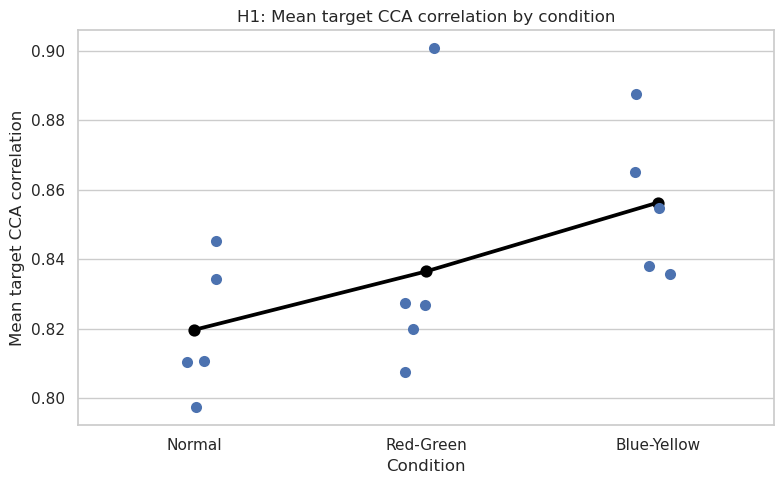

In [5]:
# Create a figure for H1 feature 1:
# mean target CCA correlation for each run in each condition
plt.figure(figsize=(8, 5))

# Show each run as an individual point
sns.stripplot(
    data=run_summary,
    x="condition_label",
    y="mean_rho_target",
    order=plot_order,
    size=8
)

# Show the condition mean as a black point connected by lines
sns.pointplot(
    data=run_summary,
    x="condition_label",
    y="mean_rho_target",
    order=plot_order,
    errorbar=None,
    color="black"
)

# Add labels and title
plt.xlabel("Condition")
plt.ylabel("Mean target CCA correlation")
plt.title("H1: Mean target CCA correlation by condition")

# Save the figure
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "h1_mean_rho_target.png", dpi=300)

# Show the figure
plt.show()

### Plot H1: mean CCA margin

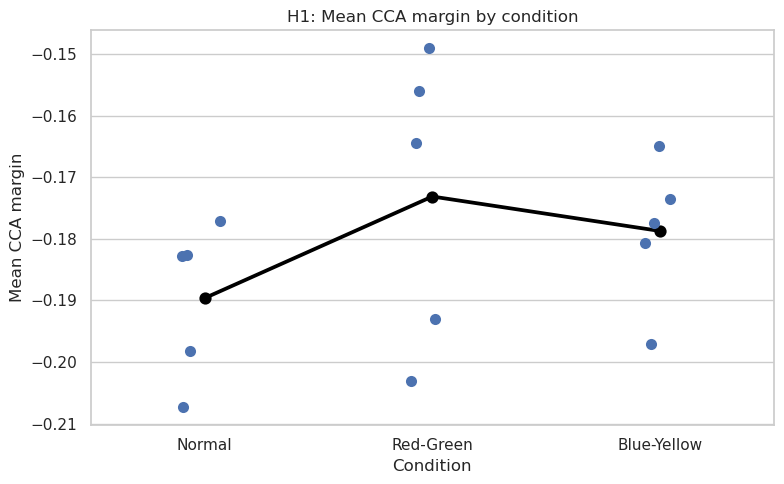

In [6]:
# Create a figure for H1 feature 2:
# mean CCA margin for each run in each condition
plt.figure(figsize=(8, 5))

# Show each run as an individual point
sns.stripplot(
    data=run_summary,
    x="condition_label",
    y="mean_rho_margin",
    order=plot_order,
    size=8
)

# Show the condition mean as a black point connected by lines
sns.pointplot(
    data=run_summary,
    x="condition_label",
    y="mean_rho_margin",
    order=plot_order,
    errorbar=None,
    color="black"
)

# Add labels and title
plt.xlabel("Condition")
plt.ylabel("Mean CCA margin")
plt.title("H1: Mean CCA margin by condition")

# Save the figure
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "h1_mean_rho_margin.png", dpi=300)

# Show the figure
plt.show()

### Plot H3: accuracy

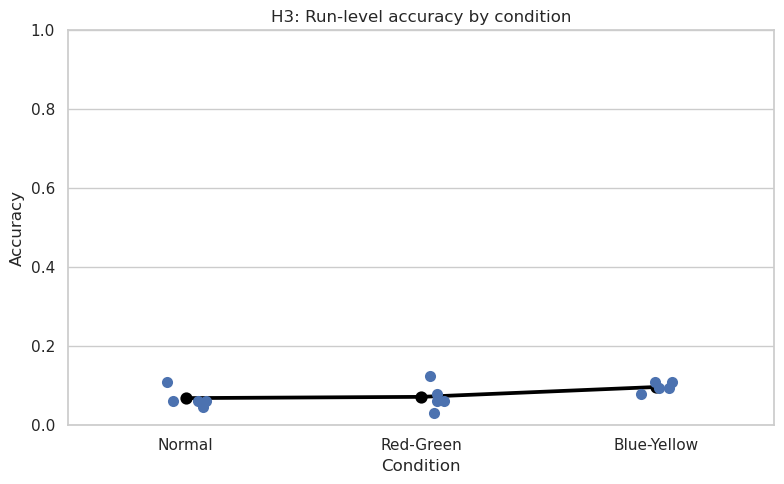

In [7]:
# Create a figure for H2 feature 1:
# classification accuracy for each run in each condition
plt.figure(figsize=(8, 5))

# Show each run as an individual point
sns.stripplot(
    data=run_summary,
    x="condition_label",
    y="accuracy",
    order=plot_order,
    size=8
)

# Show the condition mean as a black point connected by lines
sns.pointplot(
    data=run_summary,
    x="condition_label",
    y="accuracy",
    order=plot_order,
    errorbar=None,
    color="black"
)

# Add labels and title
plt.xlabel("Condition")
plt.ylabel("Accuracy")
plt.title("H3: Run-level accuracy by condition")

# Limit the y-axis to the natural range of accuracy
plt.ylim(0, 1)

# Save the figure
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "h3_accuracy.png", dpi=300)

# Show the figure
plt.show()

### Plot H3: ITR

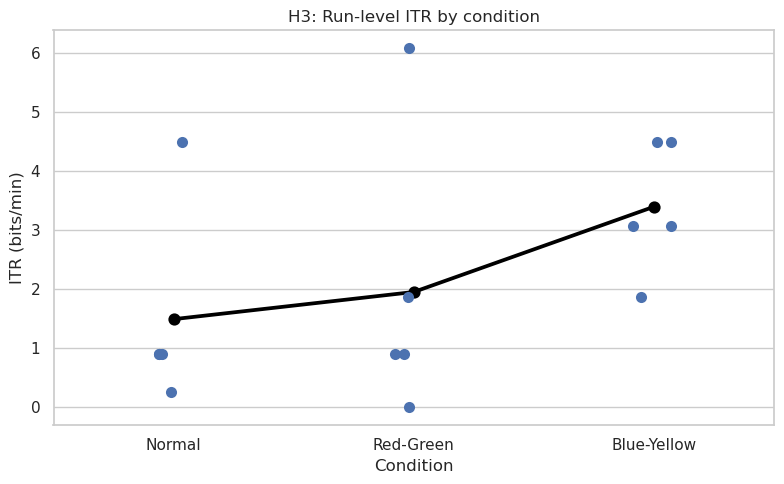

In [8]:
# Create a figure for H2 feature 2:
# Information Transfer Rate (ITR) for each run in each condition
plt.figure(figsize=(8, 5))

# Show each run as an individual point
sns.stripplot(
    data=run_summary,
    x="condition_label",
    y="ITR",
    order=plot_order,
    size=8
)

# Show the condition mean as a black point connected by lines
sns.pointplot(
    data=run_summary,
    x="condition_label",
    y="ITR",
    order=plot_order,
    errorbar=None,
    color="black"
)

# Add labels and title
plt.xlabel("Condition")
plt.ylabel("ITR (bits/min)")
plt.title("H3: Run-level ITR by condition")

# Save the figure
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "h3_itr.png", dpi=300)

# Show the figure
plt.show()

### Relationship between H1 and H2
Does stronger target correlation tend to go with higher accuracy?

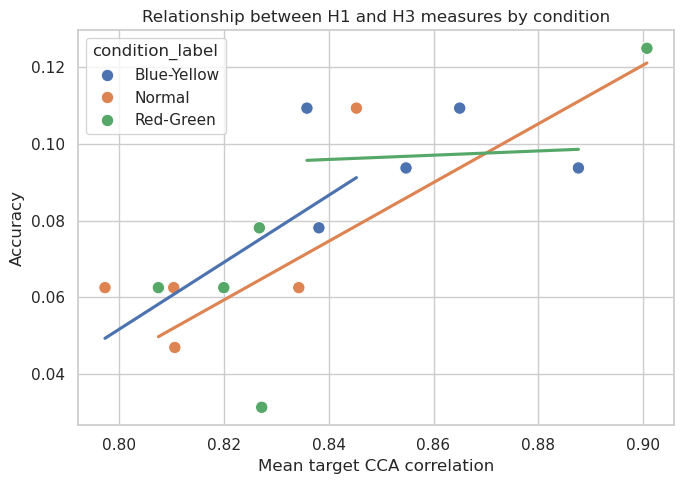

In [9]:
plt.figure(figsize=(7, 5))

# Draw scatter points for each run
sns.scatterplot(
    data=run_summary,
    x="mean_rho_target",
    y="accuracy",
    hue="condition_label",
    s=80
)

# Draw one regression line for each condition
for label in plot_order:
    subset = run_summary[run_summary["condition_label"] == label]

    sns.regplot(
        data=subset,
        x="mean_rho_target",
        y="accuracy",
        scatter=False,
        ci=None,
        label=f"{label} trend"
    )

plt.xlabel("Mean target CCA correlation")
plt.ylabel("Accuracy")
plt.title("Relationship between H1 and H3 measures by condition")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optional_rho_vs_accuracy_by_condition.png", dpi=300)
plt.show()

### Sumary

In [10]:
summary_table = (
    run_summary
    .groupby("condition_label", as_index=False)
    .agg(
        mean_rho_target=("mean_rho_target", "mean"),
        mean_rho_margin=("mean_rho_margin", "mean"),
        accuracy=("accuracy", "mean"),
        ITR=("ITR", "mean")
    )
)

summary_table

,condition_label,mean_rho_target,mean_rho_margin,accuracy,ITR
0,Blue-Yellow,0.856268,-0.178738,0.096875,3.393847
1,Normal,0.819599,-0.189640,0.068750,1.491545
2,Red-Green,0.836436,-0.173142,0.071875,1.951280
